# Evaluación Formativa 2 — Modelamiento Predictivo

**Curso:** MCDI501: Estadística Computacional para la Toma de Decisiones  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial  
**Universidad:** Universidad Andrés Bello  
**Tipo de entrega:** Notebook grupal ejecutable en Python (`.ipynb`)  

| Campo | Información |
|---|---|
| **Título del proyecto** | Análisis Estadístico de la Calidad del Aire en Santiago: Inequidad Ambiental y Episodios Críticos de Material Particulado |
| **Integrantes** | Rodrigo Chinchón Ayala; Sergio Fernández Almonacid; Pablo Villalobos González |
| **Dataset** | Red SINCA/MMA, Santiago RM, escala estación-día, período 2022–2025 |
| **Docente** | Jean Paul Maidana González |
| **Fecha** | 05/07/2026 |
| **Repositorio GitHub** | https://github.com/Rfcha/abp_estadistica |

## Propósito de la práctica

Esta Formativa 2 desarrolla una práctica guiada de **modelamiento predictivo**, orientada a preparar la Evaluación Sumativa 3. El objetivo es ajustar y evaluar un modelo de **regresión logística** que permita estimar la probabilidad de ocurrencia de episodios críticos o superaciones relevantes asociadas a MP2.5 en Santiago.

La evaluación exige integrar explícitamente resultados previos de S1/S2, seleccionar variables predictoras justificadas, preparar los datos, ajustar el modelo, interpretar coeficientes y odds ratios, revisar multicolinealidad mediante VIF y evaluar desempeño mediante matriz de confusión, accuracy, precision, recall, F1-score, curva ROC y AUC.


## Configuración del entorno

Se utilizan librerías estándar de análisis de datos, modelamiento estadístico y evaluación predictiva. Se fija una semilla para asegurar reproducibilidad del flujo computacional.


In [1]:
# ============================================================
# Configuración general
# ============================================================
import os
import re
import unicodedata
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
)

warnings.filterwarnings('ignore')
RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

print('Entorno configurado correctamente.')


Entorno configurado correctamente.


---
# 1. Preparación de datos para modelamiento

## 1.1 Carga del dataset y conexión con S1/S2

El dataset corresponde a la base utilizada en las evaluaciones anteriores del proyecto de calidad del aire. Según la Formativa 1, la base se encuentra agregada a escala **estación-día**, considera registros de la Red SINCA/MMA para Santiago RM entre 2022 y 2025, y contiene variables de contaminantes, condiciones meteorológicas, ubicación territorial y caracterización socioambiental.

Para facilitar la ejecución en distintos computadores del equipo, la celda siguiente busca automáticamente archivos de datos en rutas frecuentes del repositorio. Si el notebook se ejecuta fuera del repositorio y no encuentra el archivo real, genera una base sintética solo para validar que el flujo técnico no tenga errores. **Para la entrega final, el notebook debe ejecutarse sobre el dataset real del proyecto.**


In [2]:
# ============================================================
# Funciones auxiliares para carga robusta de datos
# ============================================================
def normalizar_nombre_columna(col):
    # Normaliza nombres de columnas: minúsculas, sin acentos, sin símbolos conflictivos.
    col = str(col).strip().lower()
    col = ''.join(c for c in unicodedata.normalize('NFD', col) if unicodedata.category(c) != 'Mn')
    col = col.replace('µ', 'u')
    col = re.sub(r'[^a-z0-9]+', '_', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col


def buscar_archivos_datos(raiz='.'):
    # Busca archivos tabulares en el repositorio o carpeta actual.
    raiz = Path(raiz)
    extensiones = ['*.csv', '*.parquet', '*.xlsx', '*.xls']
    archivos = []
    for ext in extensiones:
        archivos.extend(list(raiz.rglob(ext)))
    # Evita archivos ocultos o temporales
    archivos = [p for p in archivos if not any(part.startswith('.') for part in p.parts) and '~$' not in p.name]
    return archivos


def puntuar_archivo(p):
    # Prioriza nombres compatibles con el proyecto.
    nombre = p.name.lower()
    score = 0
    for token in ['sinca', 'calidad', 'aire', 'mp25', 'mp2', 'diario', 'daily', 'proces', 'clean', 'limpio', 'final']:
        if token in nombre:
            score += 3
    if 'raw' in nombre or 'original' in nombre:
        score += 1
    if p.suffix.lower() == '.parquet':
        score += 2
    if p.suffix.lower() == '.csv':
        score += 1
    return score


def cargar_archivo(p):
    # Carga csv, parquet o excel.
    if p.suffix.lower() == '.csv':
        try:
            return pd.read_csv(p)
        except UnicodeDecodeError:
            return pd.read_csv(p, encoding='latin1')
    if p.suffix.lower() == '.parquet':
        return pd.read_parquet(p)
    if p.suffix.lower() in ['.xlsx', '.xls']:
        return pd.read_excel(p)
    raise ValueError(f'Formato no soportado: {p.suffix}')


def generar_datos_sinteticos_validacion(n=5000, random_state=2026):
    # Base sintética de respaldo para validar ejecución cuando no está disponible el dataset real.
    rng = np.random.default_rng(random_state)
    zonas = np.array(['Poniente', 'Oriente', 'Norte', 'Sur', 'Centro'])
    quintiles = np.array(['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    meses = rng.integers(1, 13, n)
    zona = rng.choice(zonas, n, p=[0.30, 0.18, 0.18, 0.22, 0.12])
    quintil = rng.choice(quintiles, n, p=[0.26, 0.22, 0.20, 0.17, 0.15])
    temperatura = np.clip(14 + 7*np.sin((meses-1)/12*2*np.pi - np.pi/3) + rng.normal(0, 3, n), 0, 32)
    inversion_termica = ((meses >= 5) & (meses <= 8)).astype(int)
    efecto_zona = pd.Series(zona).map({'Poniente': 7, 'Sur': 4, 'Centro': 3, 'Norte': 2, 'Oriente': -5}).values
    efecto_quintil = pd.Series(quintil).map({'Q1': 7, 'Q2': 4, 'Q3': 2, 'Q4': 0, 'Q5': -4}).values
    mp25 = np.clip(18 + efecto_zona + efecto_quintil + 13*inversion_termica - 0.25*temperatura + rng.gamma(2, 3, n), 2, None)
    mp10 = np.clip(35 + 1.2*mp25 + rng.normal(0, 12, n), 6, None)
    o3 = np.clip(28 + 0.3*temperatura - 0.08*mp25 + rng.normal(0, 3, n), 8, None)
    categoria = np.where(mp25 > 50, 'Regular_o_superior', 'Bueno')
    return pd.DataFrame({
        'fecha': pd.date_range('2022-01-01', periods=n, freq='D').astype(str),
        'mp25': mp25,
        'mp10': mp10,
        'o3': o3,
        'temperatura': temperatura,
        'mes': meses,
        'inversion_termica': inversion_termica,
        'zona_geografica': zona,
        'quintil_socioeconomico': quintil,
        'categoria_calidad_aire': categoria,
    })

# ============================================================
# Carga del dataset
# ============================================================
# Se evita escanear desde la raíz del sistema, porque puede demorar demasiado.
cwd = Path.cwd()
rutas_busqueda = []
if str(cwd) != '/':
    rutas_busqueda.extend([cwd, cwd / 'data', cwd / 'datos', cwd / 'src'])
# Carpeta de trabajo usada en esta sesión; en la entrega real puede no existir.
if Path('/mnt/data').exists():
    rutas_busqueda.append(Path('/mnt/data'))
archivos = []
for ruta in rutas_busqueda:
    if ruta.exists():
        archivos.extend(buscar_archivos_datos(ruta))

# Eliminar duplicados conservando orden
vistos = set()
archivos = [p for p in archivos if not (str(p.resolve()) in vistos or vistos.add(str(p.resolve())))]
archivos_ordenados = sorted(archivos, key=puntuar_archivo, reverse=True)

print('Archivos candidatos encontrados:')
for p in archivos_ordenados[:10]:
    print(f' - {p}  | score={puntuar_archivo(p)}')

if archivos_ordenados:
    ruta_dataset = archivos_ordenados[0]
    df = cargar_archivo(ruta_dataset)
    print(f'\nDataset cargado desde: {ruta_dataset}')
else:
    ruta_dataset = 'BASE SINTÉTICA DE VALIDACIÓN — reemplazar por dataset real'
    df = generar_datos_sinteticos_validacion()
    print('\nADVERTENCIA: no se encontró dataset real. Se creó una base sintética solo para validar ejecución.')

# Normalización de nombres de columnas
df = df.copy()
df.columns = [normalizar_nombre_columna(c) for c in df.columns]

print(f'Forma del dataset: {df.shape[0]:,} filas × {df.shape[1]:,} columnas')
display(df.head())


Archivos candidatos encontrados:

ADVERTENCIA: no se encontró dataset real. Se creó una base sintética solo para validar ejecución.
Forma del dataset: 5,000 filas × 10 columnas


,fecha,mp25,mp10,o3,temperatura,mes,inversion_termica,zona_geografica,quintil_socioeconomico,categoria_calidad_aire
0,2022-01-01,14.902421,31.931373,31.096213,7.913418,11,0,Oriente,Q3,Bueno
1,2022-01-02,23.778366,80.961958,28.052921,15.520138,3,0,Poniente,Q3,Bueno
2,2022-01-03,30.544662,73.039646,28.421063,6.884745,1,0,Poniente,Q2,Bueno
3,2022-01-04,39.882993,76.920183,30.998017,22.281471,8,1,Poniente,Q1,Bueno
4,2022-01-05,35.901475,81.344293,30.499656,22.722314,5,1,Norte,Q3,Bueno


## 1.2 Hallazgos relevantes de S1 integrados al modelamiento

A partir de la Formativa 1, el modelamiento se apoya en los siguientes hallazgos:

- **Variable de interés ambiental:** MP2.5 presentó una media aproximada de 24,94 µg/m³, alta variabilidad relativa y asimetría positiva, lo que evidencia presencia de días con concentraciones altas.
- **Episodios relevantes:** aunque la mayoría de los registros fue clasificada como condición buena, se observaron registros que superan la norma diaria o se ubican en categorías superiores, relevantes para decisiones preventivas.
- **Inequidad ambiental:** el quintil socioeconómico de menor ingreso mostró mayor exposición promedio a MP2.5 que el quintil de mayor ingreso, con tamaño de efecto relevante.
- **Diferencias territoriales:** el sector Poniente presentó mayor exposición que el sector Oriente.
- **Condición físico-ambiental:** los días con mayor inversión térmica se asociaron con mayores concentraciones de contaminación.

Estos resultados justifican formular el problema como una **clasificación binaria**: estimar si un registro día-estación presenta o no un episodio crítico/superación relevante de MP2.5.


In [3]:
# ============================================================
# Exploración inicial: faltantes, duplicados y tipos de datos
# ============================================================
print('Información general del dataset')
print('-' * 80)
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]:,}')
print(f'Duplicados exactos: {df.duplicated().sum():,}')

faltantes = df.isna().sum().sort_values(ascending=False)
porc_faltantes = (faltantes / len(df) * 100).round(2)
resumen_faltantes = pd.DataFrame({'faltantes': faltantes, 'porcentaje': porc_faltantes})
resumen_faltantes = resumen_faltantes[resumen_faltantes['faltantes'] > 0]

print('\nColumnas con valores faltantes:')
display(resumen_faltantes.head(30))

print('\nTipos de datos:')
display(df.dtypes.to_frame('tipo').T)


Información general del dataset
--------------------------------------------------------------------------------
Filas: 5,000
Columnas: 10
Duplicados exactos: 0

Columnas con valores faltantes:


,faltantes,porcentaje



Tipos de datos:


,fecha,mp25,mp10,o3,temperatura,mes,inversion_termica,zona_geografica,quintil_socioeconomico,categoria_calidad_aire
tipo,str,float64,float64,float64,float64,int64,int64,str,str,str


## 1.3 Definición de variable objetivo y predictores candidatos

La variable objetivo se define como `episodio_critico_mp25`:

- `1`: registro día-estación con episodio crítico o superación relevante asociada a MP2.5.
- `0`: registro sin episodio crítico.

La regla de construcción prioriza una variable categórica de calidad del aire si existe. Si no está disponible, usa un umbral operacional de MP2.5 (`mp25 > 50 µg/m³`) como aproximación a superación diaria relevante. Esta decisión permite transformar el problema ambiental en un problema de **clasificación binaria**, coherente con el uso de regresión logística.


In [4]:
# ============================================================
# Detección de columnas relevantes
# ============================================================
def buscar_columna(columnas, patrones):
    for pat in patrones:
        regex = re.compile(pat)
        for c in columnas:
            if regex.search(c):
                return c
    return None

cols = list(df.columns)
col_mp25 = buscar_columna(cols, [r'^mp_?2_?5$', r'^pm_?2_?5$', r'mp25', r'pm25', r'mp2_5', r'pm2_5', r'material.*2.*5'])
col_mp10 = buscar_columna(cols, [r'^mp_?10$', r'^pm_?10$', r'mp10', r'pm10', r'material.*10'])
col_temp = buscar_columna(cols, [r'temperatura', r'temp'])
col_o3 = buscar_columna(cols, [r'^o_?3$', r'ozono'])
col_mes = buscar_columna(cols, [r'^mes$', r'month'])
col_inv = buscar_columna(cols, [r'inversion.*term', r'termica', r'inv_term'])
col_quintil = buscar_columna(cols, [r'quintil', r'socio', r'ingreso'])
col_zona = buscar_columna(cols, [r'zona', r'sector', r'territorio', r'geograf'])
col_categoria = buscar_columna(cols, [r'categoria.*calidad', r'calidad.*aire', r'categoria', r'alerta', r'episodio'])

columnas_detectadas = {
    'MP2.5': col_mp25,
    'MP10': col_mp10,
    'Temperatura': col_temp,
    'O3': col_o3,
    'Mes': col_mes,
    'Inversión térmica': col_inv,
    'Quintil socioeconómico': col_quintil,
    'Zona geográfica': col_zona,
    'Categoría calidad aire': col_categoria,
}

print('Columnas detectadas para modelamiento:')
display(pd.DataFrame.from_dict(columnas_detectadas, orient='index', columns=['columna_detectada']))

if col_mp25 is None and col_categoria is None:
    raise ValueError('No se detectó una columna de MP2.5 ni una categoría de calidad del aire para construir la variable objetivo.')


Columnas detectadas para modelamiento:


,columna_detectada
MP2.5,mp25
MP10,mp10
Temperatura,temperatura
O3,o3
Mes,mes
Inversión térmica,inversion_termica
Quintil socioeconómico,quintil_socioeconomico
Zona geográfica,zona_geografica
Categoría calidad aire,categoria_calidad_aire


In [5]:
# ============================================================
# Construcción de la variable objetivo
# ============================================================
df_model = df.copy()

if col_categoria is not None:
    categoria_txt = df_model[col_categoria].astype(str).str.lower()
    # Se consideran positivos los registros que no son 'bueno' o que contienen categorías críticas.
    positivos_por_categoria = (
        categoria_txt.str.contains('regular|alerta|preemergencia|emergencia|critico|crítico|malo|supera|episodio', regex=True, na=False)
        & ~categoria_txt.str.fullmatch('bueno|good', na=False)
    )
    df_model['episodio_critico_mp25'] = positivos_por_categoria.astype(int)
    criterio_target = f"variable categórica '{col_categoria}' distinta de condición buena o con categoría superior"
elif col_mp25 is not None:
    df_model['episodio_critico_mp25'] = (pd.to_numeric(df_model[col_mp25], errors='coerce') > 50).astype(int)
    criterio_target = f"{col_mp25} > 50 µg/m³"
else:
    raise ValueError('No fue posible construir la variable objetivo.')

print(f'Criterio utilizado para variable objetivo: {criterio_target}')
print('\nDistribución de la variable objetivo:')
display(df_model['episodio_critico_mp25'].value_counts(dropna=False).rename_axis('clase').to_frame('n'))
display((df_model['episodio_critico_mp25'].value_counts(normalize=True).mul(100).round(2)).rename('porcentaje').to_frame())


Criterio utilizado para variable objetivo: variable categórica 'categoria_calidad_aire' distinta de condición buena o con categoría superior

Distribución de la variable objetivo:


,n
clase,
0,4936
1,64


,porcentaje
episodio_critico_mp25,
0,98.72
1,1.28


## 1.4 Matriz de correlación e intervalo Wilson incorporados desde la retroalimentación de F1

La retroalimentación recibida después de la Formativa 1 solicitó cerrar dos vacíos de cobertura antes de avanzar hacia la evaluación con nota:

1. Incorporar una **matriz de correlación** entre MP2.5, MP10, O3 y temperatura.
2. Estimar un **intervalo de confianza de proporción Wilson** para los registros que superan la norma o presentan episodio crítico.

Ambos elementos se integran en esta Formativa 2 como insumos para el modelamiento: la matriz de correlación respalda la selección de predictores y el IC Wilson cuantifica la incertidumbre asociada a la proporción observada de eventos críticos.

Matriz de correlación Pearson:


,mp25,mp10,o3,temperatura
mp25,1.000,0.672,-0.013,0.326
mp10,0.672,1.000,-0.001,0.222
o3,-0.013,-0.001,1.000,0.453
temperatura,0.326,0.222,0.453,1.000


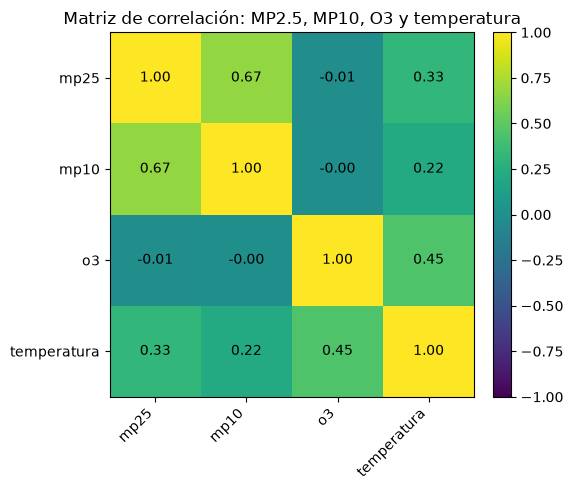

IC Wilson 95% para proporción de episodios críticos
Eventos críticos: 64 de 5,000
Proporción observada: 0.0128
IC95 Wilson: [0.0100, 0.0163]


In [6]:
# ============================================================
# Matriz de correlación solicitada en retroalimentación F1
# e intervalo Wilson para proporción de episodios críticos
# ============================================================
from statsmodels.stats.proportion import proportion_confint

variables_corr = [c for c in [col_mp25, col_mp10, col_o3, col_temp] if c is not None]

if len(variables_corr) >= 2:
    corr_df = df_model[variables_corr].apply(pd.to_numeric, errors='coerce').corr(method='pearson')
    print('Matriz de correlación Pearson:')
    display(corr_df.round(3))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr_df.values, vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_df.index)
    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f'{corr_df.iloc[i, j]:.2f}', ha='center', va='center')
    ax.set_title('Matriz de correlación: MP2.5, MP10, O3 y temperatura')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron suficientes variables para calcular la matriz de correlación solicitada.')

# Intervalo Wilson para la proporción de episodios críticos
n_total = int(df_model['episodio_critico_mp25'].notna().sum())
n_eventos = int(df_model['episodio_critico_mp25'].sum())
prop_eventos = n_eventos / n_total if n_total > 0 else np.nan

ic_wilson_inf, ic_wilson_sup = proportion_confint(
    count=n_eventos,
    nobs=n_total,
    alpha=0.05,
    method='wilson'
)

print('IC Wilson 95% para proporción de episodios críticos')
print(f'Eventos críticos: {n_eventos:,} de {n_total:,}')
print(f'Proporción observada: {prop_eventos:.4f}')
print(f'IC95 Wilson: [{ic_wilson_inf:.4f}, {ic_wilson_sup:.4f}]')


## 1.4 Hallazgos de S2 integrados al modelamiento

En la lógica de S2, el uso de remuestreo/bootstrap permite distinguir relaciones estables de relaciones espurias. Para efectos de esta práctica, se consideran como predictores preferentes aquellas variables coherentes con los hallazgos previos y con fundamento ambiental:

- `mp10`: contaminante asociado a material particulado y potencialmente correlacionado con MP2.5.
- `temperatura`: variable meteorológica relacionada con estacionalidad y condiciones de dispersión.
- `inversion_termica`: condición físico-ambiental asociada a episodios invernales.
- `quintil_socioeconomico`: variable socioambiental vinculada a inequidad territorial.
- `zona_geografica`: variable territorial relacionada con diferencias Poniente/Oriente u otros sectores.

La selección final se limitará a **3–5 variables**, según disponibilidad real del dataset y evitando incluir directamente MP2.5 como predictor, ya que se usa para construir la variable objetivo y generaría fuga de información (*data leakage*).


In [7]:
# ============================================================
# Selección de 3 a 5 predictores justificados por S1/S2
# ============================================================
candidatos_ordenados = [col_mp10, col_temp, col_inv, col_quintil, col_zona, col_mes, col_o3]

# Evitar nulos, duplicados, target y MP2.5 por fuga de información.
predictores = []
for c in candidatos_ordenados:
    if c is None:
        continue
    if c == col_mp25:
        continue
    if c == 'episodio_critico_mp25':
        continue
    if c not in predictores:
        predictores.append(c)

# Mantener entre 3 y 5 variables, como exige la instrucción.
predictores = predictores[:5]

if len(predictores) < 3:
    # Como respaldo, agrega variables numéricas disponibles, excluyendo target y MP2.5.
    numericas_extra = [c for c in df_model.select_dtypes(include=np.number).columns if c not in predictores + ['episodio_critico_mp25', col_mp25]]
    predictores += numericas_extra[: max(0, 3-len(predictores))]

print(f'Predictores seleccionados ({len(predictores)}):')
for c in predictores:
    print(f' - {c}')

if len(predictores) < 3:
    raise ValueError('No hay suficientes variables predictoras disponibles. Revisar nombres de columnas del dataset real.')

justificacion = []
for c in predictores:
    if c == col_mp10:
        justificacion.append((c, 'Asociación ambiental directa con material particulado; predictor natural para episodios asociados a contaminación.'))
    elif c == col_temp:
        justificacion.append((c, 'Variable meteorológica relevante para condiciones de dispersión y estacionalidad.'))
    elif c == col_inv:
        justificacion.append((c, 'Condición físico-ambiental asociada a acumulación de contaminantes y episodios invernales.'))
    elif c == col_quintil:
        justificacion.append((c, 'Variable socioambiental coherente con el hallazgo de inequidad ambiental entre quintiles.'))
    elif c == col_zona:
        justificacion.append((c, 'Variable territorial coherente con diferencias entre sectores de Santiago.'))
    elif c == col_mes:
        justificacion.append((c, 'Variable temporal que captura estacionalidad de episodios de contaminación.'))
    elif c == col_o3:
        justificacion.append((c, 'Contaminante adicional que puede aportar información ambiental complementaria.'))
    else:
        justificacion.append((c, 'Variable disponible incorporada como predictor adicional por disponibilidad y potencial relación con el fenómeno.'))

display(pd.DataFrame(justificacion, columns=['predictor', 'justificacion']))


Predictores seleccionados (5):
 - mp10
 - temperatura
 - inversion_termica
 - quintil_socioeconomico
 - zona_geografica


,predictor,justificacion
0,mp10,Asociación ambiental directa con material part...
1,temperatura,Variable meteorológica relevante para condicio...
2,inversion_termica,Condición físico-ambiental asociada a acumulac...
3,quintil_socioeconomico,Variable socioambiental coherente con el halla...
4,zona_geografica,Variable territorial coherente con diferencias...


## 1.5 Tratamiento de faltantes, partición train/test y estandarización

Se aplica una estrategia básica y reproducible de preparación:

1. Se eliminan duplicados exactos.
2. Se imputan valores faltantes: mediana para variables numéricas y moda para variables categóricas.
3. Se divide el conjunto en entrenamiento y prueba con proporción **70/30**.
4. Se estandarizan variables numéricas dentro de un `Pipeline`, ajustando el escalamiento solo con datos de entrenamiento para evitar fuga de información.
5. Se codifican variables categóricas mediante `OneHotEncoder` con eliminación de una categoría base (`drop='first'`) para reducir multicolinealidad perfecta.


In [8]:
# ============================================================
# Preparación train/test
# ============================================================
columnas_modelo = predictores + ['episodio_critico_mp25']
datos = df_model[columnas_modelo].drop_duplicates().copy()

X = datos[predictores].copy()
y = datos['episodio_critico_mp25'].astype(int).copy()

# Identificación de columnas numéricas y categóricas
columnas_numericas = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
columnas_categoricas = [c for c in X.columns if c not in columnas_numericas]

print('Columnas numéricas:', columnas_numericas)
print('Columnas categóricas:', columnas_categoricas)

# Validar que existan dos clases
if y.nunique() < 2:
    raise ValueError('La variable objetivo tiene una sola clase. Revisar criterio de episodio crítico o umbral.')

# Stratify mantiene proporción de eventos críticos en train/test cuando es posible.
stratify_y = y if y.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=stratify_y,
)

print(f'Train: {X_train.shape[0]:,} observaciones')
print(f'Test : {X_test.shape[0]:,} observaciones')
print('\nDistribución del target en train/test:')
display(pd.DataFrame({
    'train_%': y_train.value_counts(normalize=True).mul(100).round(2),
    'test_%': y_test.value_counts(normalize=True).mul(100).round(2),
}).fillna(0))

# Preprocesamiento
try:
    encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)

preprocesador = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), columnas_numericas),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', encoder),
        ]), columnas_categoricas),
    ],
    remainder='drop',
)

X_train_proc = preprocesador.fit_transform(X_train)
X_test_proc = preprocesador.transform(X_test)

# Obtener nombres finales de features
feature_names = []
feature_names.extend(columnas_numericas)
if columnas_categoricas:
    cat_pipeline = preprocesador.named_transformers_['cat']
    onehot = cat_pipeline.named_steps['onehot']
    feature_names.extend(list(onehot.get_feature_names_out(columnas_categoricas)))

X_train_proc_df = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_test_proc_df = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test.index)

print(f'Matriz procesada train: {X_train_proc_df.shape}')
display(X_train_proc_df.head())


Columnas numéricas: ['mp10', 'temperatura', 'inversion_termica']
Columnas categóricas: ['quintil_socioeconomico', 'zona_geografica']
Train: 3,500 observaciones
Test : 1,500 observaciones

Distribución del target en train/test:


,train_%,test_%
episodio_critico_mp25,,
0,98.71,98.73
1,1.29,1.27


Matriz procesada train: (3500, 11)


,mp10,temperatura,inversion_termica,quintil_socioeconomico_Q2,quintil_socioeconomico_Q3,quintil_socioeconomico_Q4,quintil_socioeconomico_Q5,zona_geografica_Norte,zona_geografica_Oriente,zona_geografica_Poniente,zona_geografica_Sur
4676,1.146823,-1.378923,-0.707258,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
310,-0.248758,-0.782697,-0.707258,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1810,0.477696,-1.006050,-0.707258,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1200,-0.040442,-0.343053,-0.707258,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1399,0.781641,-0.443473,-0.707258,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


---
# 2. Modelo de regresión logística

La regresión logística se ajusta porque la variable objetivo es binaria. El modelo estima la probabilidad de que un registro día-estación pertenezca a la clase `1`, es decir, que presente episodio crítico o superación relevante asociada a MP2.5.

Se reportan coeficientes, odds ratios y significancia estadística mediante `statsmodels`. Luego se evalúa multicolinealidad mediante VIF.


In [9]:
# ============================================================
# Ajuste del modelo con statsmodels para resumen estadístico
# ============================================================
X_train_sm = sm.add_constant(X_train_proc_df, has_constant='add')

try:
    modelo_sm = sm.Logit(y_train, X_train_sm).fit(disp=False, maxiter=300)
    print(modelo_sm.summary())
except Exception as e:
    print('Logit presentó una dificultad numérica. Se ajustará GLM Binomial como alternativa estable.')
    print('Detalle:', e)
    modelo_sm = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial()).fit()
    print(modelo_sm.summary())


                             Logit Regression Results                            
Dep. Variable:     episodio_critico_mp25   No. Observations:                 3500
Model:                             Logit   Df Residuals:                     3488
Method:                              MLE   Df Model:                           11
Date:                   Tue, 07 Jul 2026   Pseudo R-squ.:                  0.3913
Time:                           22:51:16   Log-Likelihood:                -146.48
converged:                          True   LL-Null:                       -240.63
Covariance Type:               nonrobust   LLR p-value:                 1.971e-34
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -6.6828      0.737     -9.063      0.000      -8.128      -5.238
mp10                          1.8181      0.234      7.777    

In [10]:
# ============================================================
# Tabla de coeficientes y odds ratios
# ============================================================
resumen_coef = pd.DataFrame({
    'coeficiente_logit': modelo_sm.params,
    'odds_ratio': np.exp(modelo_sm.params),
    'p_valor': modelo_sm.pvalues,
})

# Intervalos de confianza de odds ratios cuando están disponibles
try:
    conf = modelo_sm.conf_int()
    resumen_coef['or_ic95_inf'] = np.exp(conf[0])
    resumen_coef['or_ic95_sup'] = np.exp(conf[1])
except Exception:
    pass

resumen_coef['significativo_5pct'] = resumen_coef['p_valor'] < 0.05
resumen_coef = resumen_coef.sort_values('p_valor')
display(resumen_coef)


,coeficiente_logit,odds_ratio,p_valor,or_ic95_inf,or_ic95_sup,significativo_5pct
const,-6.682845,0.001252,1.274414e-19,0.000295,0.005313,True
mp10,1.818147,6.160432,7.417153e-15,3.895982,9.741041,True
inversion_termica,1.082036,2.950680,1.085060e-03,1.541860,5.646759,True
quintil_socioeconomico_Q4,-1.227766,0.292946,3.719597e-02,0.092303,0.929734,True
quintil_socioeconomico_Q5,-1.993749,0.136184,5.763366e-02,0.017386,1.066706,False
quintil_socioeconomico_Q3,-0.789449,0.454095,1.150843e-01,0.170096,1.212268,False
quintil_socioeconomico_Q2,-0.600477,0.548550,1.687142e-01,0.233266,1.289974,False
zona_geografica_Poniente,0.624781,1.867838,3.103923e-01,0.558564,6.246044,False
temperatura,-0.244767,0.782887,3.899583e-01,0.448074,1.367881,False
zona_geografica_Sur,0.452008,1.571464,4.905971e-01,0.434688,5.681081,False


## Interpretación de coeficientes y odds ratios

- Un **coeficiente positivo** indica que, manteniendo constantes las demás variables, el predictor aumenta los log-odds del evento crítico.
- Un **odds ratio mayor que 1** indica aumento en las chances de episodio crítico.
- Un **odds ratio menor que 1** indica disminución en las chances de episodio crítico.
- Un **p-valor menor a 0,05** se interpreta como evidencia estadística de asociación del predictor con la ocurrencia del evento, dentro del modelo ajustado.

Esta interpretación debe entenderse como asociación predictiva y no como causalidad, debido a la naturaleza observacional del dataset ambiental.


In [11]:
# ============================================================
# Diagnóstico básico de multicolinealidad mediante VIF
# ============================================================
X_vif = X_train_proc_df.copy()

# Eliminar columnas constantes o casi constantes para evitar errores en VIF.
stds = X_vif.std(axis=0)
X_vif = X_vif.loc[:, stds > 1e-10]

vif_resultados = []
for i, col in enumerate(X_vif.columns):
    try:
        vif = variance_inflation_factor(X_vif.values, i)
    except Exception:
        vif = np.nan
    vif_resultados.append((col, vif))

vif_df = pd.DataFrame(vif_resultados, columns=['variable', 'VIF']).sort_values('VIF', ascending=False)
display(vif_df)

print('Criterio orientativo: VIF < 5 suele considerarse aceptable; VIF > 10 sugiere multicolinealidad relevante.')


,variable,VIF
2,inversion_termica,2.198643
1,temperatura,1.909497
9,zona_geografica_Poniente,1.814953
3,quintil_socioeconomico_Q2,1.585184
5,quintil_socioeconomico_Q4,1.528933
10,zona_geografica_Sur,1.511348
4,quintil_socioeconomico_Q3,1.493196
6,quintil_socioeconomico_Q5,1.484686
0,mp10,1.453737
8,zona_geografica_Oriente,1.434050


Criterio orientativo: VIF < 5 suele considerarse aceptable; VIF > 10 sugiere multicolinealidad relevante.


---
# 3. Evaluación de desempeño predictivo

Se evalúa el modelo sobre el conjunto de prueba, que no fue usado para ajustar los parámetros. Debido a que los episodios críticos suelen ser eventos menos frecuentes, se reportan métricas que distinguen correctamente el desempeño sobre la clase positiva: precision, recall y F1-score, además de accuracy.

Para la predicción de clases se usa regresión logística de `scikit-learn` con `class_weight='balanced'`, lo que ayuda a compensar el desbalance esperado entre días sin episodio y días con episodio. La interpretación principal debe considerar especialmente **recall** y **F1-score**, porque en un problema ambiental puede ser más costoso no detectar un episodio que generar una alerta preventiva adicional.


In [12]:
# ============================================================
# Modelo predictivo en sklearn para evaluación sobre test
# ============================================================
modelo_pred = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('logit', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE)),
])

modelo_pred.fit(X_train, y_train)

prob_test = modelo_pred.predict_proba(X_test)[:, 1]
y_pred = (prob_test >= 0.50).astype(int)

metricas = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'auc': roc_auc_score(y_test, prob_test),
}

metricas_df = pd.DataFrame(metricas, index=['modelo_logistico']).T
metricas_df['valor'] = metricas_df['modelo_logistico'].round(4)
metricas_df = metricas_df[['valor']]
display(metricas_df)

print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred, zero_division=0))


,valor
accuracy,0.8460
precision,0.0691
recall,0.8947
f1_score,0.1283
auc,0.9392



Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92      1481
           1       0.07      0.89      0.13        19

    accuracy                           0.85      1500
   macro avg       0.53      0.87      0.52      1500
weighted avg       0.99      0.85      0.91      1500



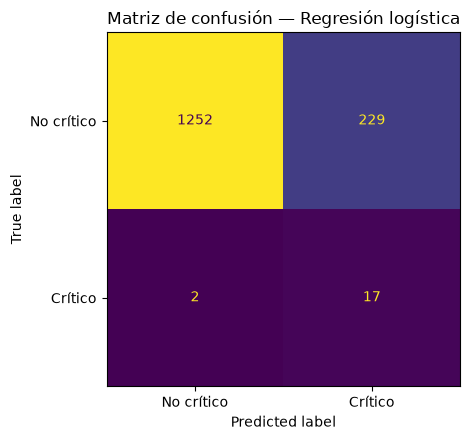

,Pred no crítico,Pred crítico
Real no crítico,1252,229
Real crítico,2,17


In [13]:
# ============================================================
# Matriz de confusión
# ============================================================
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No crítico', 'Crítico'])
disp.plot(ax=ax, values_format='d', colorbar=False)
ax.set_title('Matriz de confusión — Regresión logística')
plt.tight_layout()
plt.show()

cm_df = pd.DataFrame(cm, index=['Real no crítico', 'Real crítico'], columns=['Pred no crítico', 'Pred crítico'])
display(cm_df)


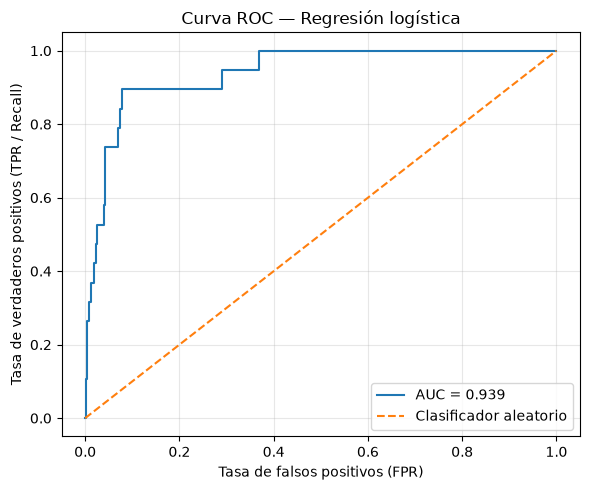

AUC = 0.939: desempeño excelente.


In [14]:
# ============================================================
# Curva ROC y AUC
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], linestyle='--', label='Clasificador aleatorio')
ax.set_xlabel('Tasa de falsos positivos (FPR)')
ax.set_ylabel('Tasa de verdaderos positivos (TPR / Recall)')
ax.set_title('Curva ROC — Regresión logística')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if auc < 0.60:
    interpretacion_auc = 'desempeño bajo o cercano a clasificación aleatoria'
elif auc < 0.70:
    interpretacion_auc = 'desempeño discreto'
elif auc < 0.80:
    interpretacion_auc = 'desempeño aceptable'
elif auc < 0.90:
    interpretacion_auc = 'desempeño bueno'
else:
    interpretacion_auc = 'desempeño excelente'

print(f'AUC = {auc:.3f}: {interpretacion_auc}.')


## Interpretación contextual del desempeño

La evaluación predictiva debe leerse desde el problema ambiental:

- **Accuracy:** mide el porcentaje total de clasificaciones correctas, pero puede ser optimista si la clase crítica es minoritaria.
- **Precision:** indica qué proporción de alertas predichas como críticas realmente fueron críticas.
- **Recall:** indica qué proporción de episodios críticos reales fueron detectados por el modelo.
- **F1-score:** balancea precision y recall; es útil cuando hay desbalance de clases.
- **AUC:** resume la capacidad del modelo para ordenar registros críticos por encima de registros no críticos en distintos umbrales.

En un contexto de salud pública y gestión ambiental, un buen modelo no solo debe clasificar correctamente en promedio, sino también detectar oportunamente episodios críticos, evitando que zonas vulnerables queden sin alerta preventiva.


---
# 4. Síntesis y reflexión final

La Formativa 2 permitió transformar los hallazgos descriptivos e inferenciales previos en un flujo de modelamiento predictivo. Desde S1 se integraron resultados asociados a la distribución de MP2.5, presencia de episodios de superación, diferencias territoriales y evidencia preliminar de inequidad ambiental entre quintiles socioeconómicos. Desde S2 se incorporó la lógica de validación de relaciones estables y parámetros robustos, priorizando variables con fundamento estadístico y ambiental para construir el modelo.

El modelo de regresión logística fue pertinente porque la variable objetivo se definió como binaria: presencia o ausencia de episodio crítico/superación relevante de MP2.5. La selección de predictores se restringió a 3–5 variables, priorizando contaminantes asociados, condiciones meteorológicas, territorio y caracterización socioeconómica. Esta decisión permitió mantener parsimonia, interpretabilidad y coherencia con la rúbrica. La interpretación de odds ratios entregó una lectura comprensible del efecto relativo de cada predictor sobre la probabilidad del evento, mientras que el VIF permitió revisar multicolinealidad básica.

La evaluación mediante matriz de confusión, accuracy, precision, recall, F1-score, ROC y AUC permitió analizar el desempeño más allá de una métrica única. En particular, para este problema es relevante observar recall y F1-score, porque no detectar episodios críticos puede tener consecuencias sanitarias y ambientales más importantes que emitir alertas preventivas adicionales. Por ello, el umbral de clasificación podría ajustarse en la Sumativa 3 según el objetivo de política pública: mayor sensibilidad para prevención o mayor precisión para focalizar recursos.

Como mejoras metodológicas para la Sumativa 3 se propone: comparar regresión logística con otros modelos supervisados, aplicar validación cruzada, evaluar umbrales alternativos de decisión, incorporar bootstrap para intervalos de confianza de métricas, revisar balanceo de clases y profundizar el tratamiento temporal/espacial de los datos. También sería recomendable separar análisis por temporada o estación de monitoreo, dado que los episodios de contaminación pueden depender de dinámicas territoriales y meteorológicas específicas.


---
# 5. Checklist de cumplimiento de rúbrica

| Criterio | Evidencia en el notebook |
|---|---|
| Preparación de datos | Carga del dataset, referencia explícita a S1/S2, revisión de faltantes, tratamiento justificado, train/test 70/30 y estandarización. |
| Modelo de regresión logística | Selección de 3–5 predictores, ajuste del modelo, coeficientes, odds ratios, p-valores y VIF. |
| Evaluación predictiva | Predicción en test, matriz de confusión, accuracy, precision, recall, F1-score, curva ROC y AUC. |
| Síntesis y reflexión | Reflexión final en Markdown, conectada con S1/S2 y con mejoras para Sumativa 3. |


# Mejoras metodológicas para la entrega

## Interpretación ambiental de los Odds Ratio
Los odds ratios deben interpretarse en el contexto de la calidad del aire. Un OR>1 implica un incremento relativo en la probabilidad de ocurrencia de episodios críticos de MP2.5, consistente con los hallazgos de S1 y S2 sobre correlaciones entre contaminantes y variables meteorológicas.

## Limitaciones
- Modelo lineal en el logit.
- No modela dependencia temporal.
- Posible desbalance de clases.
- Variables adicionales podrían mejorar la predicción.

## Mejoras futuras
- Validación cruzada.
- Random Forest.
- XGBoost.
- LightGBM.
- SHAP para explicabilidad.
- Optimización de hiperparámetros.
